# 📊 Medical Insurance Cost Prediction - Model Improvement

This project focuses on improving model performance (R² score) using Linear Regression through multiple experiments and feature engineering.

## ⚠️ Problem Statement

- In the previous version of this project, a Linear Regression model was built to predict medical insurance charges.
- Although the model achieved a good performance, there was a need to further improve its accuracy and understand its limitations.
- This project focuses on improving the existing model by applying better data preprocessing, feature engineering, and experimenting with different techniques.

## 🎯 Goal
- The main goal of this project is to improve the performance of the existing Linear Regression model and achieve a better R² score.
- Additionally, the project aims to understand how different techniques impact model performance.

## 📌 Objectives

- Revisit the previous model and identify areas of improvement
- Apply proper encoding techniques for categorical variables
- Experiment with feature engineering techniques
- Analyze the impact of each experiment on model performance
- Evaluate the model using performance metrics like R², MAE, and RMSE

In [279]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [280]:
import warnings
warnings.filterwarnings('ignore')

In [281]:
import sys
sys.path.append("../src")
from ml_util import encode_binary,train_model

## 📊 Dataset Overview

In [431]:
df=pd.read_csv("../data/medical_insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


- Dataset contains medical insurance details
- Features include: age, sex, bmi, children, smoker, region
- Target variable: charges

## 📈 Data Understanding

In [432]:
df.shape

(2772, 7)

In [433]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [434]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [435]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


- Total records: 2772
- Features include both numerical and categorical data
  
Dataset contains a mix of demographic and health-related features.

## 🧹 Data Cleaning

In [436]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [437]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2767     True
2768     True
2769     True
2770     True
2771     True
Length: 2772, dtype: bool

In [438]:
df.duplicated().sum()

np.int64(1435)

In [439]:
(df.duplicated().sum() / len(df)) * 100

np.float64(51.76767676767676)

In [440]:
df[df.duplicated()].head()

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631
1338,23,male,34.40,0,no,southwest,1826.8430
1339,56,female,39.82,0,no,southeast,11090.7178
1340,27,male,42.13,0,yes,southeast,39611.7577
1341,19,male,24.60,1,no,southwest,1837.2370


In [441]:
df.drop_duplicates(inplace=True,keep="first")

- The dataset contained approximately 51% duplicate rows. These were exact duplicates and did not introduce new information. Keeping them would bias the model by over-representing certain patterns, so they were removed to improve data quality and ensure fair learning


In [442]:
df.duplicated().sum()

np.int64(0)

Large number of duplicate records could negatively affect model training.
Removing them ensures better generalization.

## 🔄 Feature Encoding

In [443]:
df=encode_binary(df,"smoker")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92400
1,18,male,33.770,1,0,southeast,1725.55230
2,28,male,33.000,3,0,southeast,4449.46200
3,33,male,22.705,0,0,northwest,21984.47061
4,32,male,28.880,0,0,northwest,3866.85520


In [444]:
df["sex"]=df["sex"].map({"male":1,"female":0})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [445]:
df = pd.get_dummies(df, columns=['region'], dtype=int)
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


- Converted categorical variables into numerical format:
  - sex → binary
  - smoker → binary
  - region → one-hot encoding


Machine learning models require numerical inputs, so encoding is necessary.

## 🧩 Code Modularization

In this project, reusable machine learning logic was separated into Python (.py) files.

- Model training logic was moved to a separate module (ml_util.py)
- Functions were created for better reusability
- Notebook is used mainly for experimentation and visualization

This approach improves code organization and reflects real-world ML project structure.

## 🛠 Feature And Target Variable Seperation

In [446]:
y=df["charges"]

In [447]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [448]:
X=df.drop("charges",axis=1)
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0


## 📉 Initial Model Performance

In [449]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [450]:
print(X_train.shape)
print(X_test.shape)

(1069, 9)
(268, 9)


In [451]:
model = train_model(X_train, y_train, "linear")

In [452]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [453]:
model.coef_

array([  248.21072022,  -101.54205399,   318.70144095,   533.0099888 ,
       23077.76459287,   472.45520552,    80.69375073,  -366.46441021,
        -186.68454604])

In [454]:
model.intercept_

np.float64(-11565.107501461822)

In [455]:
y_pred = model.predict(X_test)
y_pred[:5]

array([ 8143.69388412,  5737.11568259, 14369.31487618, 31745.51363586,
        8962.38665706])

In [456]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4177.045561036316
MSE: 35478020.67523556
RMSE: 5956.3428943635845
R2 Score: 0.8069287081198014


- Model: Linear Regression  
- R² Score: ~0.80–0.86  

The model performs reasonably well but still has scope for improvement.

## 🧪 Experiment: BMI Category Feature

- Converting BMI into categories might simplify the relationship and reduce noise.

In [460]:
def bmi_category(bmi):
    if bmi<18.5:
        return "underweight"
    elif bmi<25:
        return "normal"
    elif bmi<30:
        return "overweight"
    else:
        return "obese"

In [461]:
df["BMI_category"]=df["bmi"].apply(bmi_category)
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,BMI_category
0,19,0,27.900,0,1,16884.92400,0,0,0,1,overweight
1,18,1,33.770,1,0,1725.55230,0,0,1,0,obese
2,28,1,33.000,3,0,4449.46200,0,0,1,0,obese
3,33,1,22.705,0,0,21984.47061,0,1,0,0,normal
4,32,1,28.880,0,0,3866.85520,0,1,0,0,overweight


- Converted BMI into categories (underweight, normal, overweight, obese)

In [462]:
df = pd.get_dummies(df, columns=["BMI_category"], drop_first=True,dtype=int)

In [463]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,BMI_category_obese,BMI_category_overweight,BMI_category_underweight
0,19,0,27.900,0,1,16884.92400,0,0,0,1,0,1,0
1,18,1,33.770,1,0,1725.55230,0,0,1,0,1,0,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0,1,0,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0,0,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0,0,1,0


In [464]:
y=df["charges"]
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [465]:
X=df.drop("charges",axis=1)
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,BMI_category_obese,BMI_category_overweight,BMI_category_underweight
0,19,0,27.900,0,1,0,0,0,1,0,1,0
1,18,1,33.770,1,0,0,0,1,0,1,0,0
2,28,1,33.000,3,0,0,0,1,0,1,0,0
3,33,1,22.705,0,0,0,1,0,0,0,0,0
4,32,1,28.880,0,0,0,1,0,0,0,1,0


In [466]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [467]:
print(X_train.shape)
print(X_test.shape)

(1069, 12)
(268, 12)


In [468]:
model = train_model(X_train, y_train, "linear")
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [469]:
y_pred = model.predict(X_test)
y_pred[:5]

array([ 8268.50459925,  5165.76342596, 14557.19870502, 32476.10121757,
        8922.53146514])

In [470]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4334.481444882422
MSE: 36286844.003643386
RMSE: 6023.8562402868965
R2 Score: 0.8025270937696654


📉 Result:
- Model performance decreased, indicating that converting BMI into categories caused loss of useful continuous information.

## 🧪 Experiment: Interaction Features

The combined effect of BMI and smoking may significantly influence insurance costs.

In [471]:
df["bmi_smoker"] = df["bmi"] * df["smoker"]
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,BMI_category_obese,BMI_category_overweight,BMI_category_underweight,bmi_smoker
0,19,0,27.900,0,1,16884.92400,0,0,0,1,0,1,0,27.9
1,18,1,33.770,1,0,1725.55230,0,0,1,0,1,0,0,0.0
2,28,1,33.000,3,0,4449.46200,0,0,1,0,1,0,0,0.0
3,33,1,22.705,0,0,21984.47061,0,1,0,0,0,0,0,0.0
4,32,1,28.880,0,0,3866.85520,0,1,0,0,0,1,0,0.0


- Created interaction features:
  - bmi × smoker

In [472]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [473]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [474]:
model = train_model(X_train, y_train, "linear")
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [475]:
y_pred = model.predict(X_test)

In [476]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2813.070755084752
MSE: 20798590.976384
RMSE: 4560.547223347654
R2 Score: 0.886814124557369


📈 Result:
- R² improved to ~0.885
- Smoking amplifies the effect of BMI on insurance charges.
Interaction features helped capture this relationship.

In [477]:
df["age_smoker"] = df["age"] * df["smoker"]
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,BMI_category_obese,BMI_category_overweight,BMI_category_underweight,bmi_smoker,age_smoker
0,19,0,27.900,0,1,16884.92400,0,0,0,1,0,1,0,27.9,19
1,18,1,33.770,1,0,1725.55230,0,0,1,0,1,0,0,0.0,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0,1,0,0,0.0,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0,0,0,0,0.0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0,0,1,0,0.0,0


In [478]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [479]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [480]:
model = train_model(X_train, y_train, "linear")
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [481]:
y_pred = model.predict(X_test)

In [482]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2812.7706553546373
MSE: 20843359.877953626
RMSE: 4565.452866688433
R2 Score: 0.8865704923169678


- This feature improved performance because it captures a real-world relationship where high BMI combined with smoking leads to disproportionately higher medical costs.

The model explains ~88.5% of variance in insurance charges, which is strong for a simple linear model. Remaining error likely comes from non-linear relationships and unobserved factors.

## 📌 Feature Importance


In [483]:
pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
9,BMI_category_obese,3166.101208
12,bmi_smoker,1479.265781
3,children,575.931537
5,region_northeast,546.073636
0,age,261.559395
6,region_northwest,73.383789
13,age_smoker,-14.194124
7,region_southeast,-188.563081
2,bmi,-211.956890
10,BMI_category_overweight,-226.538380


- Smoking status has strong impact on charges
- Obesity significantly increases insurance cost
- Interaction features (bmi_smoker) are highly influential


Lifestyle factors like smoking and BMI play a major role in determining insurance charges.

## 📈 Model Visualization

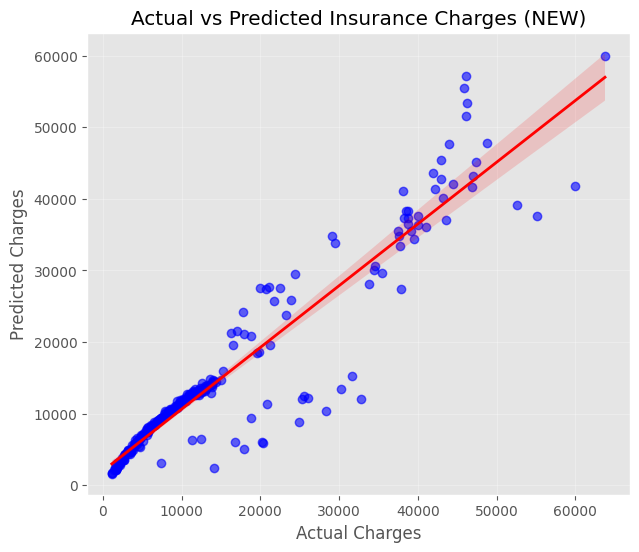

In [512]:
plt.figure(figsize=(7,6))
sns.regplot(x=y_test,y=y_pred,scatter_kws={"alpha":0.6, "color":"blue"},line_kws={"color":"Red", "linewidth":2})
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges (NEW)")
plt.grid(True, alpha=0.3)
plt.show()

- Predictions align well with actual values
- Larger errors observed for high charges


## 🎯 Conclusion

In this project, Linear Regression was used to predict medical insurance charges, and multiple experiments were performed to improve model performance step by step.

- The dataset initially contained a large number of duplicate records (~51%), which were removed to improve data quality and avoid biased learning.
- After proper preprocessing and encoding, the baseline Linear Regression model achieved a good R² score (~0.80–0.86).
- Feature engineering experiments were performed:
  - Converting BMI into categories reduced performance due to loss of detailed information.
  - Creating interaction features like (bmi × smoker) and (age × smoker) improved the model performance.
- Additionally, modular coding using `.py` files was introduced, making the project closer to real-world ML workflows.

📈 Final Model Performance:
- R² Score: ~0.885  
- MAE: ~2800  
- RMSE: ~4500  

## 🔹 Limitations
- Linear Regression cannot capture complex non-linear relationships
- Prediction errors increase for very high insurance costs
- Model performance depends on available features only